# import all

In [5]:
'/home/hmf/work/FA_test/nb/check_focalplane.py'
import sys
from fiberassign.hardware import load_hardware
from fiberassign.assign import read_assignment_fits_tile
from test_MUST_fp import *
import os
os.environ["DESIMODEL"] = os.path.expanduser("~/work/FA_test/desi")
print(os.environ["DESIMODEL"])
from fiberassign.hardware import radec2xy
import sys
from fiberassign.hardware import load_hardware
from fiberassign.assign import read_assignment_fits_tile
import sys
sys.path.append('/home/hmf/work/software/must_fbautil-main/python/')
from utils import *
import ezdxf
import glob
from shapely.ops import unary_union, polygonize
from shapely.geometry import LineString, Polygon, MultiLineString, MultiPoint
import numpy as np

/home/hmf/work/FA_test/desi


In [13]:
% matplotl

UsageError: Line magic function `%` not found.


In [ ]:
# =========================
# 读取 PLY 文件
# =========================
def read_ply(filename):
    """读取简单的 PLY 文件，返回 vertices 和 edges"""
    vertices = []
    edges = []
    
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    # 解析 header
    i = 0
    n_vertices = 0
    n_edges = 0
    
    while i < len(lines):
        line = lines[i].strip()
        if line.startswith('element vertex'):
            n_vertices = int(line.split()[-1])
        elif line.startswith('element edge'):
            n_edges = int(line.split()[-1])
        elif line == 'end_header':
            i += 1
            break
        i += 1
    
    # 读取顶点
    for j in range(n_vertices):
        parts = lines[i + j].strip().split()
        vertices.append([float(parts[0]), float(parts[1]), float(parts[2])])
    
    # 读取边
    for j in range(n_edges):
        parts = lines[i + n_vertices + j].strip().split()
        edges.append([int(parts[0]), int(parts[1])])
    
    return np.array(vertices), np.array(edges)


# =========================
# 可视化 PLY 验证
# =========================
def plot_ply_verification(segments_ply="segments.ply", boundary_ply="outer_boundary.ply"):
    """
    读取保存的 PLY 文件并可视化：
    - 外轮廓（红色边框）
    - 内部区域（灰色填充）
    - 内部线段（深灰色线条）
    """
    # 读取边界
    boundary_verts, boundary_edges = read_ply(boundary_ply)
    
    # 读取 segments
    segments_verts, segments_edges = read_ply(segments_ply)
    
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # 1. 内部区域灰色填充（基于外边界）
    from matplotlib.patches import Polygon
    polygon = Polygon(boundary_verts[:, :2], 
                      closed=True, 
                      facecolor='lightgray', 
                      edgecolor='none',
                      alpha=0.5,
                      zorder=1)
    ax.add_patch(polygon)
    
    # 2. 绘制内部线段（深灰色）
    for edge in segments_edges:
        v1 = segments_verts[edge[0], :2]
        v2 = segments_verts[edge[1], :2]
        ax.plot([v1[0], v2[0]], [v1[1], v2[1]], 
                color='dimgray', linewidth=0.8, alpha=0.7, zorder=2)
    
    # 3. 绘制外边界（红色粗线）
    for edge in boundary_edges:
        v1 = boundary_verts[edge[0], :2]
        v2 = boundary_verts[edge[1], :2]
        ax.plot([v1[0], v2[0]], [v1[1], v2[1]], 
                color='red', linewidth=2.5, zorder=3)
    
    # 4. 标记顶点（可选，用于调试）
    # ax.scatter(boundary_verts[:, 0], boundary_verts[:, 1], 
    #           c='red', s=30, zorder=4, label='Boundary vertices')
    # ax.scatter(segments_verts[:, 0], segments_verts[:, 1], 
    #           c='blue', s=10, zorder=5, label='Segment vertices')
    
    # 设置图形属性
    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('PLY out line (red)')
    ax.grid(True, alpha=0.3)
    
    # 自动调整显示范围
    all_verts = np.vstack([boundary_verts[:, :2], segments_verts[:, :2]])
    x_min, y_min = all_verts.min(axis=0) - 10
    x_max, y_max = all_verts.max(axis=0) + 10
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    plt.tight_layout()
    plt.show()
    
    # 打印统计信息
    print(f"边界顶点数: {len(boundary_verts)}")
    print(f"边界边数: {len(boundary_edges)}")
    print(f"内部顶点数: {len(segments_verts)}")
    print(f"内部边数: {len(segments_edges)}")
    print(f"边界是否闭合: {boundary_edges[0][0] == boundary_edges[-1][1]}")

from shapely.ops import unary_union, polygonize
from shapely.geometry import LineString, Polygon, MultiLineString, MultiPoint
import numpy as np

# =========================
# 保存 segments → PLY
# =========================
def save_segments_to_ply(segments, filename):
    vertices = []
    edges = []
    vid = 0

    for seg in segments:
        pts = seg.T
        n = len(pts)

        pts3d = np.hstack([pts, np.zeros((n, 1))])
        vertices.extend(pts3d)

        for i in range(n - 1):
            edges.append([vid + i, vid + i + 1])

        vid += n

    vertices = np.array(vertices)
    edges = np.array(edges)

    with open(filename, 'w') as f:
        f.write("ply\nformat ascii 1.0\n")
        f.write(f"element vertex {len(vertices)}\n")
        f.write("property float x\nproperty float y\nproperty float z\n")
        f.write(f"element edge {len(edges)}\n")
        f.write("property int vertex1\nproperty int vertex2\n")
        f.write("end_header\n")

        for v in vertices:
            f.write(f"{v[0]} {v[1]} {v[2]}\n")

        for e in edges:
            f.write(f"{e[0]} {e[1]}\n")
def save_boundary_to_ply(boundary, filename):
    n = len(boundary)

    vertices = np.hstack([boundary, np.zeros((n, 1))])
    edges = [[i, (i + 1) % n] for i in range(n)]

    with open(filename, 'w') as f:
        f.write("ply\nformat ascii 1.0\n")
        f.write(f"element vertex {n}\n")
        f.write("property float x\nproperty float y\nproperty float z\n")
        f.write(f"element edge {n}\n")
        f.write("property int vertex1\nproperty int vertex2\n")
        f.write("end_header\n")

        for v in vertices:
            f.write(f"{v[0]} {v[1]} {v[2]}\n")

        for e in edges:
            f.write(f"{e[0]} {e[1]}\n")

# # =========================
# # 修改主程序
# # =========================
# if __name__=='__main__':

#     folder_path = '/home/hmf/work/FA_test/MUST_FP/2026.04.15/'

#     # 获取所有子文件夹名
#     subfolders = [name for name in os.listdir(folder_path) 
#                 if os.path.isdir(os.path.join(folder_path, name))]
    
#     for name in subfolders:
#         dname = os.path.join(folder_path, name)
#         # print( glob.glob(f'{dname}/2026-04-2*.dxf')[0])
#         fname = glob.glob(f'{dname}/2026-04-27*.dxf')[0]
#         segments = get_dxf_points(fname)

#         print("保存 segments.ply...")
#         save_segments_to_ply(segments[-336:], f"{dname}/segments.ply")

#         print("提取外边界...")
#         boundary = get_outer_boundary(segments[-336:])

#         print("保存 outer_boundary.ply...")
#         save_boundary_to_ply(boundary, f"{dname}/outer_boundary.ply")

#         print("从 PLY 文件读取并验证...")
#         plot_ply_verification(f"{dname}/segments.ply", f"{dname}/outer_boundary.ply")

#         print("完成！")

# save ply

保存 segments.ply...
✅ 保存 PLY: 2016 顶点, 336 面 → /home/hmf/work/FA_test/MUST_FP/2026.04.15/Framed-GlobalGap4.4mm-ModuleWalls/segments.ply
提取外边界...
收集线段...
总线段数: 336
尝试方法1: 合并线段提取轮廓...
合并后类型: MultiLineString
✅ 方法1成功: 1117 个边界点
简化后: 216 个边界点
保存 outer_boundary.ply...
✅ 保存边界 PLY: 216 顶点, 1 面 → /home/hmf/work/FA_test/MUST_FP/2026.04.15/Framed-GlobalGap4.4mm-ModuleWalls/outer_boundary.ply
从 PLY 文件读取并验证...
顶点数: 2016
面数: 336
顶点数: 216
面数: 1
完成！
保存 segments.ply...
✅ 保存 PLY: 2016 顶点, 336 面 → /home/hmf/work/FA_test/MUST_FP/2026.04.15/Framed-GlobalGap4.4mm-NoModuleWalls/segments.ply
提取外边界...
收集线段...
总线段数: 336
尝试方法1: 合并线段提取轮廓...
合并后类型: MultiLineString
✅ 方法1成功: 1117 个边界点
简化后: 216 个边界点
保存 outer_boundary.ply...
✅ 保存边界 PLY: 216 顶点, 1 面 → /home/hmf/work/FA_test/MUST_FP/2026.04.15/Framed-GlobalGap4.4mm-NoModuleWalls/outer_boundary.ply
从 PLY 文件读取并验证...
顶点数: 2016
面数: 336
顶点数: 216
面数: 1
完成！
保存 segments.ply...
✅ 保存 PLY: 2016 顶点, 336 面 → /home/hmf/work/FA_test/MUST_FP/2026.04.15/SemiFrameless-GlobalGap4.4mm-Inner

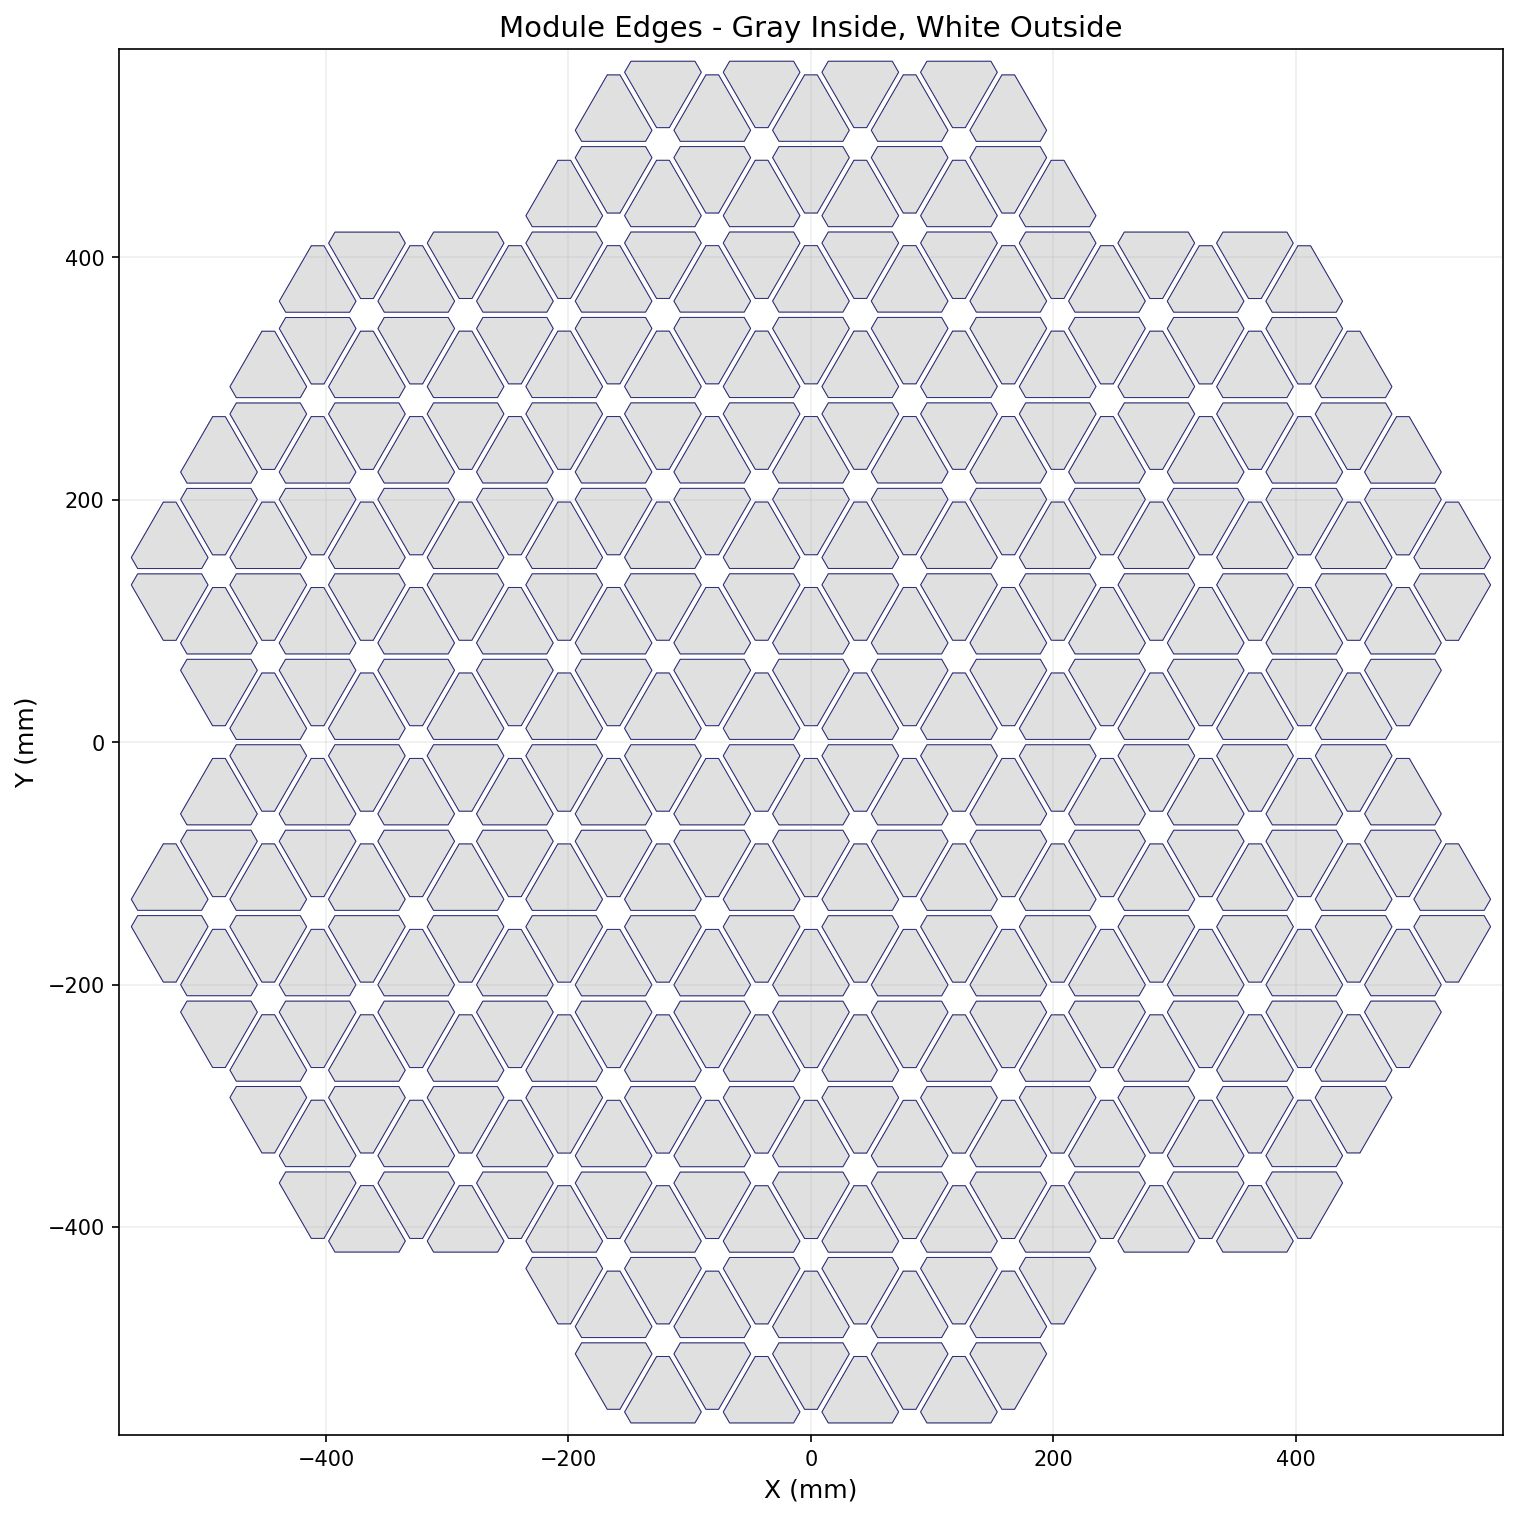

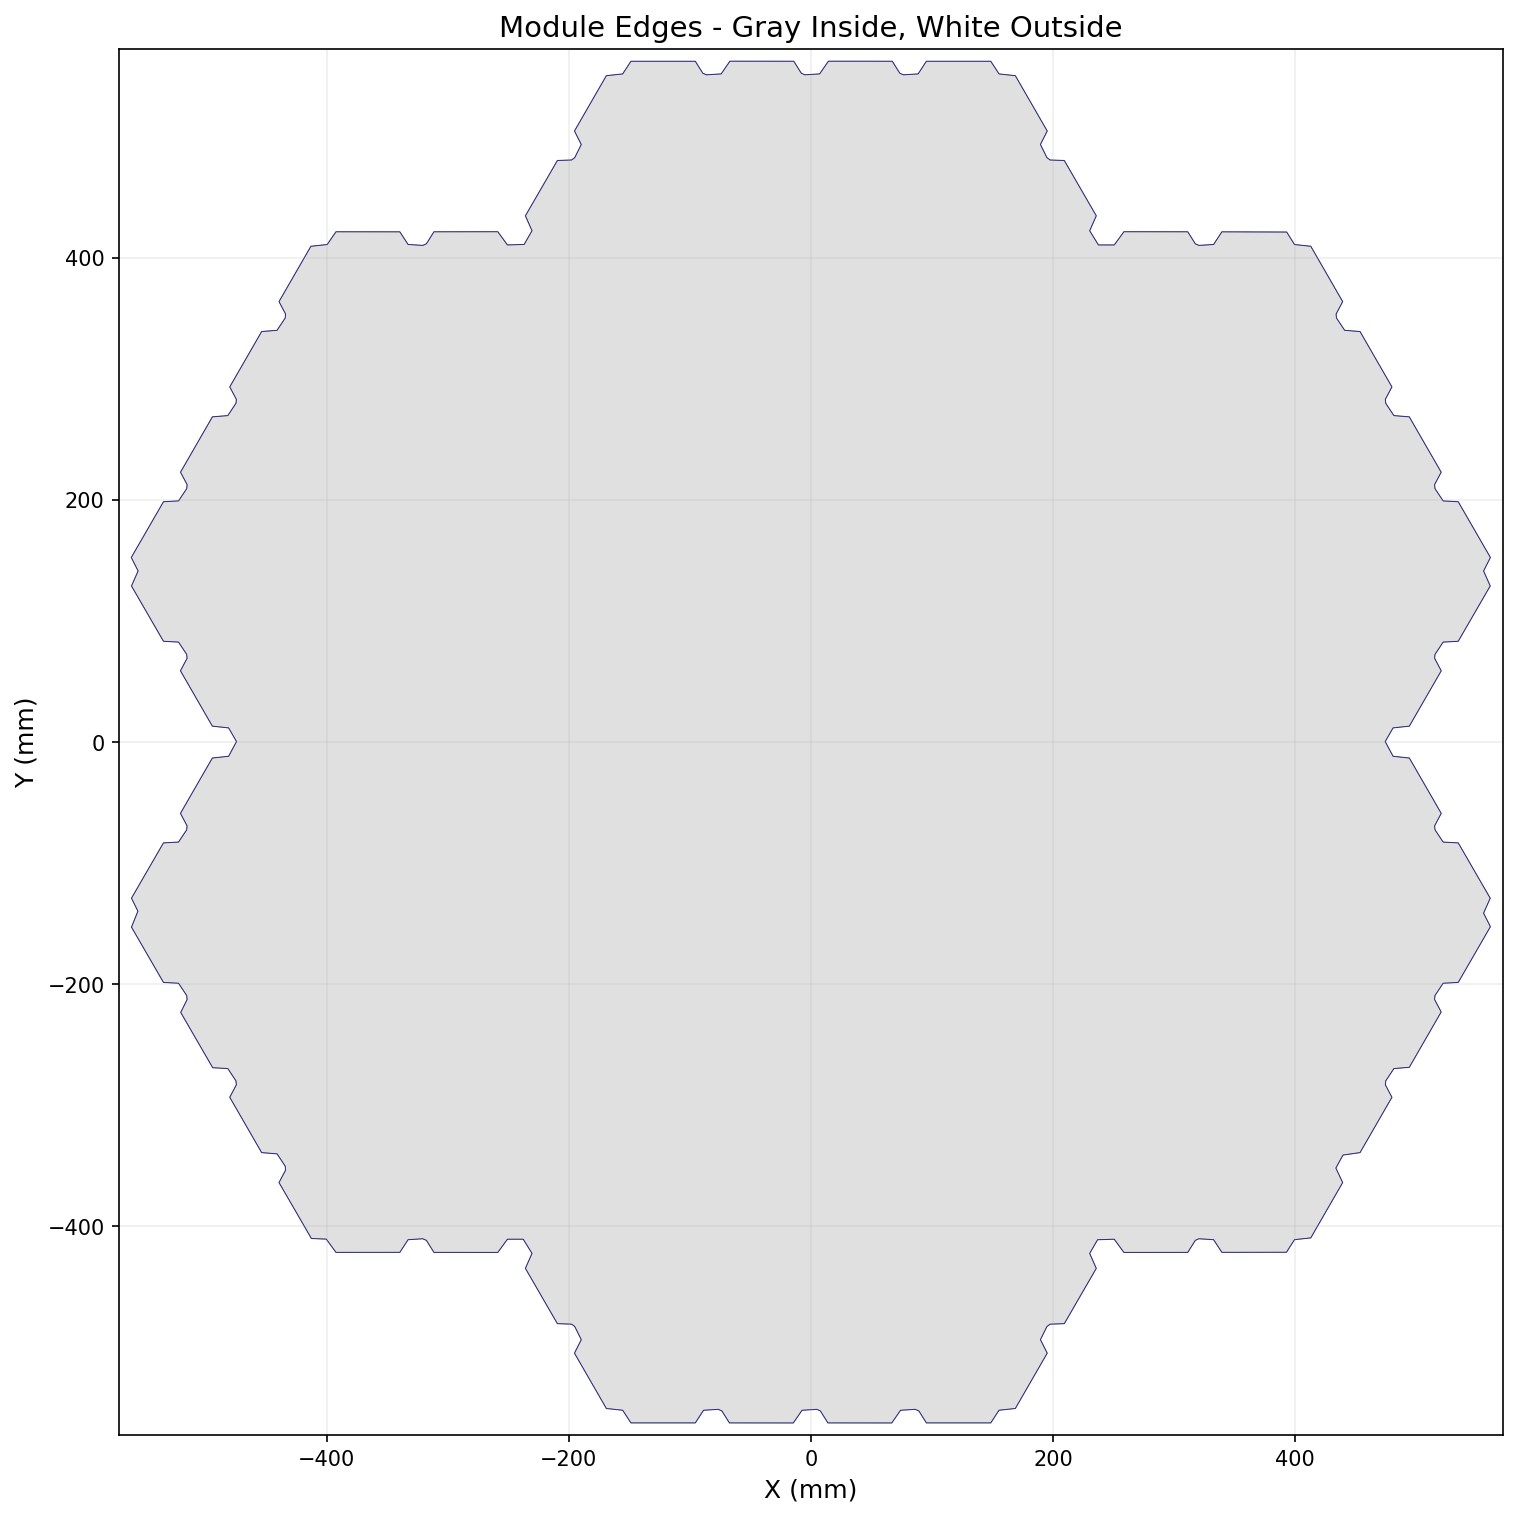

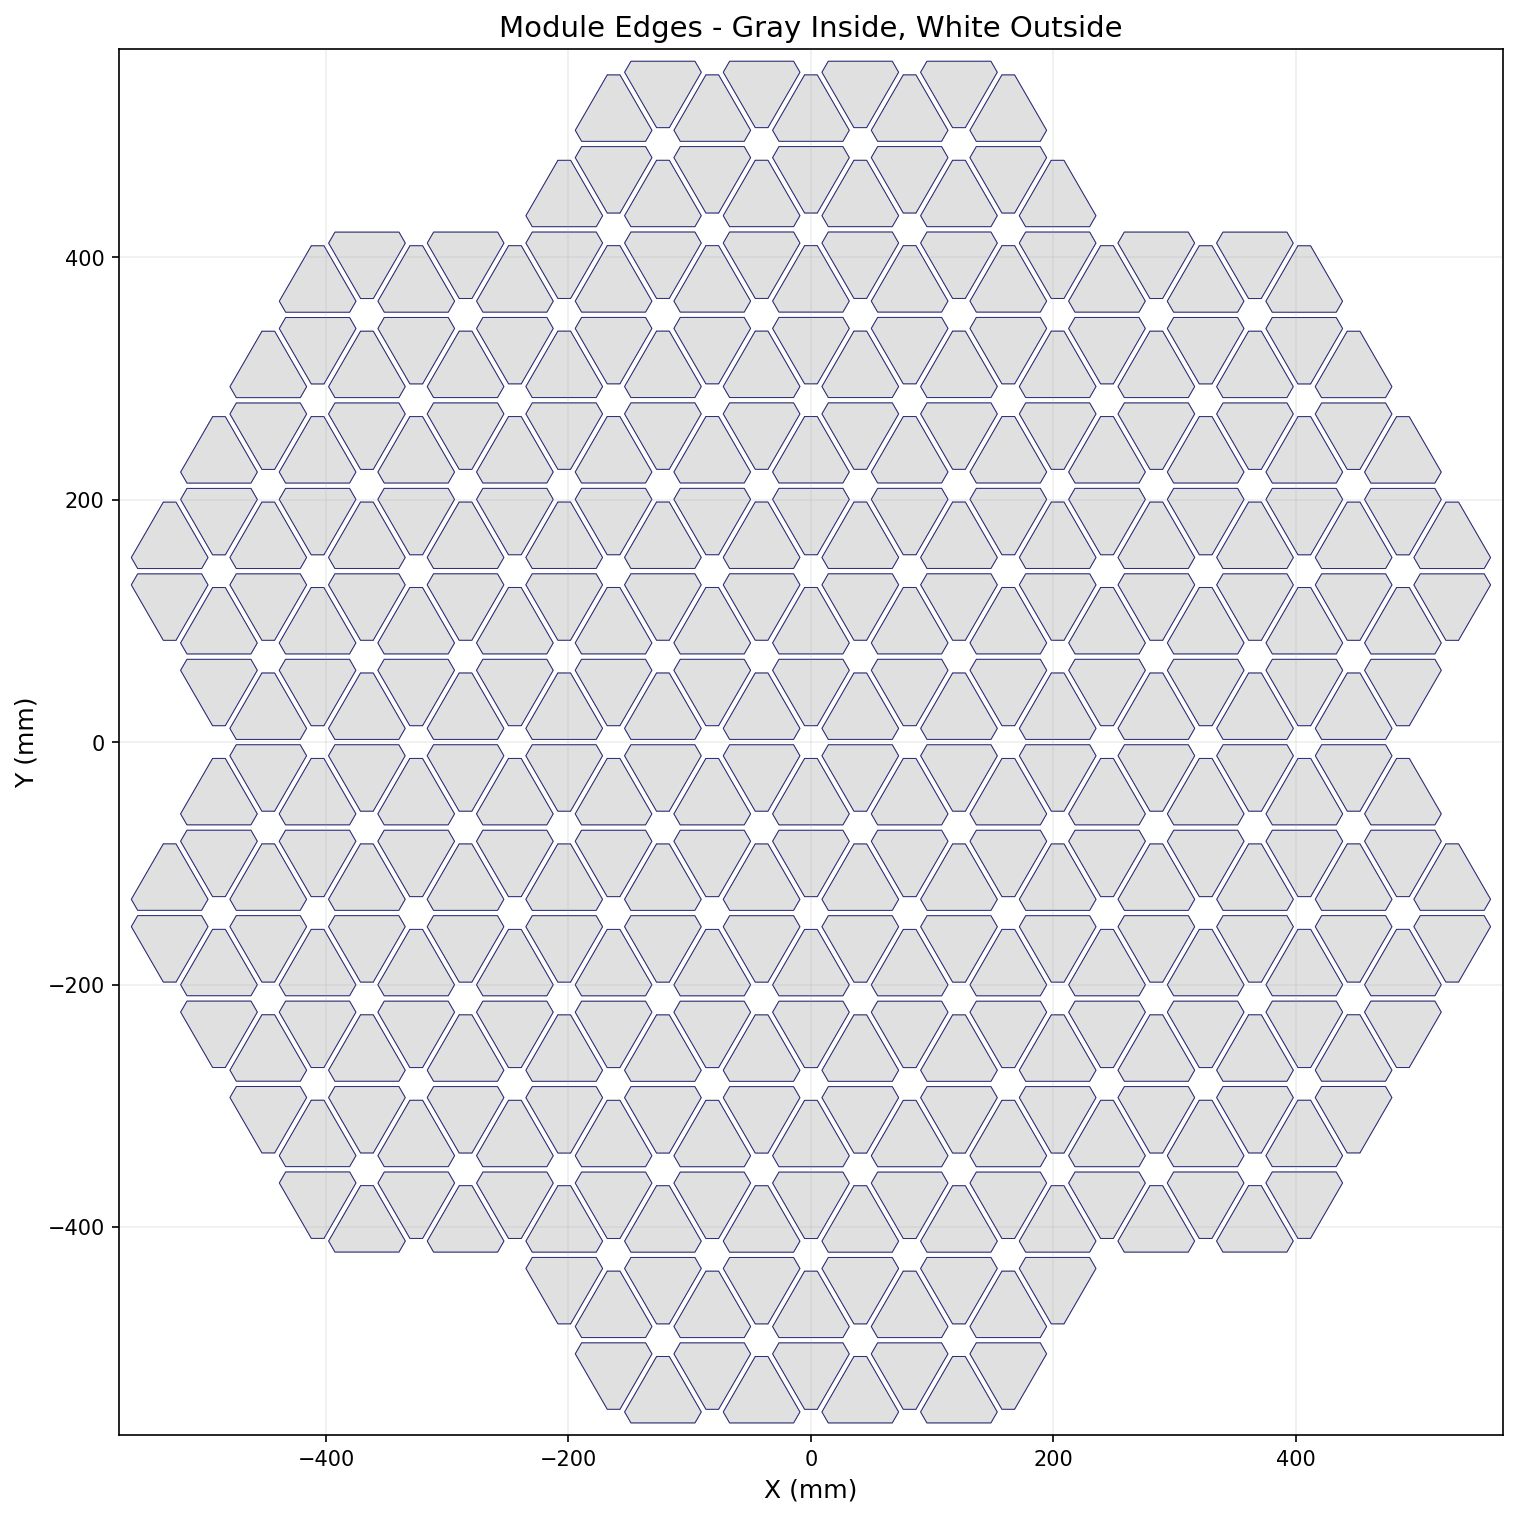

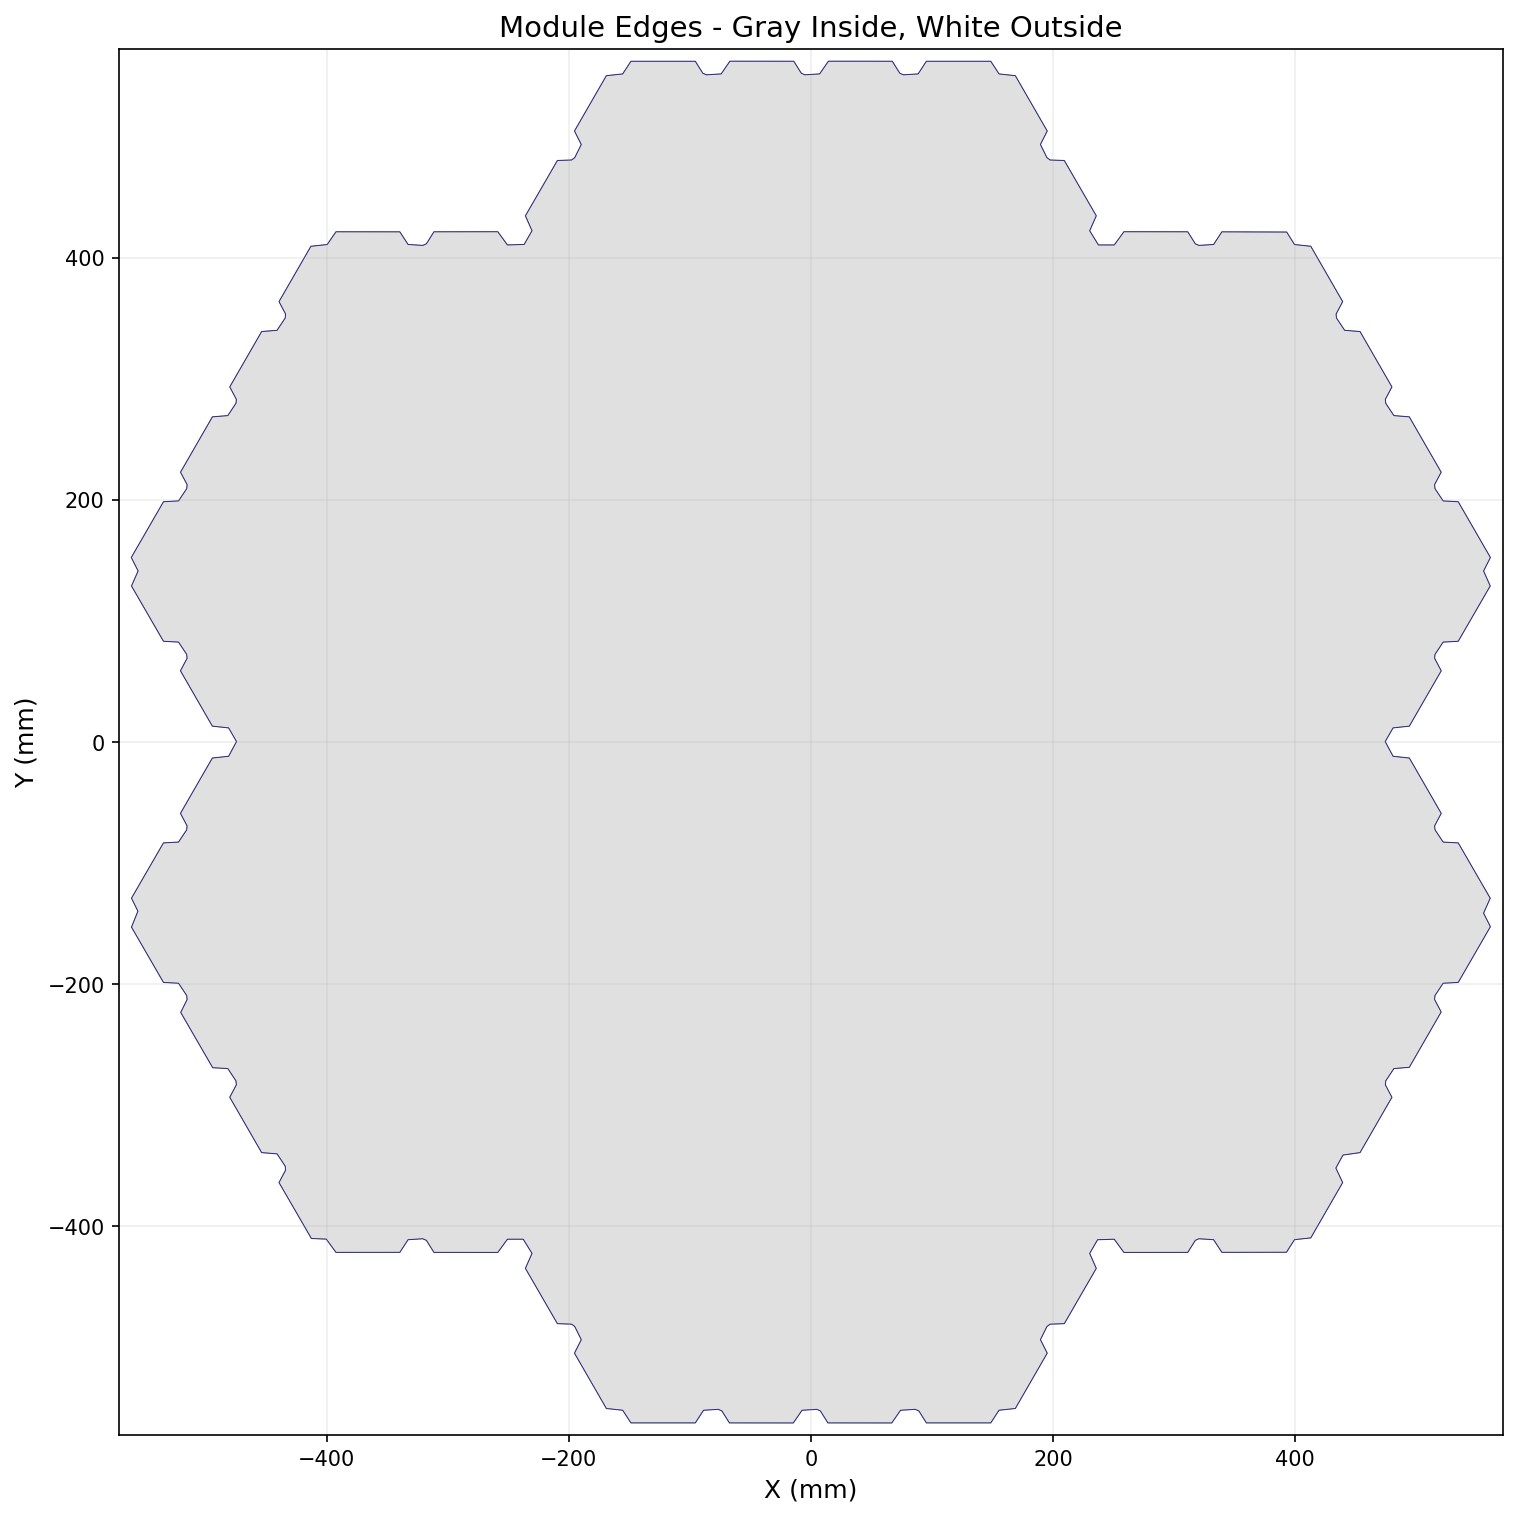

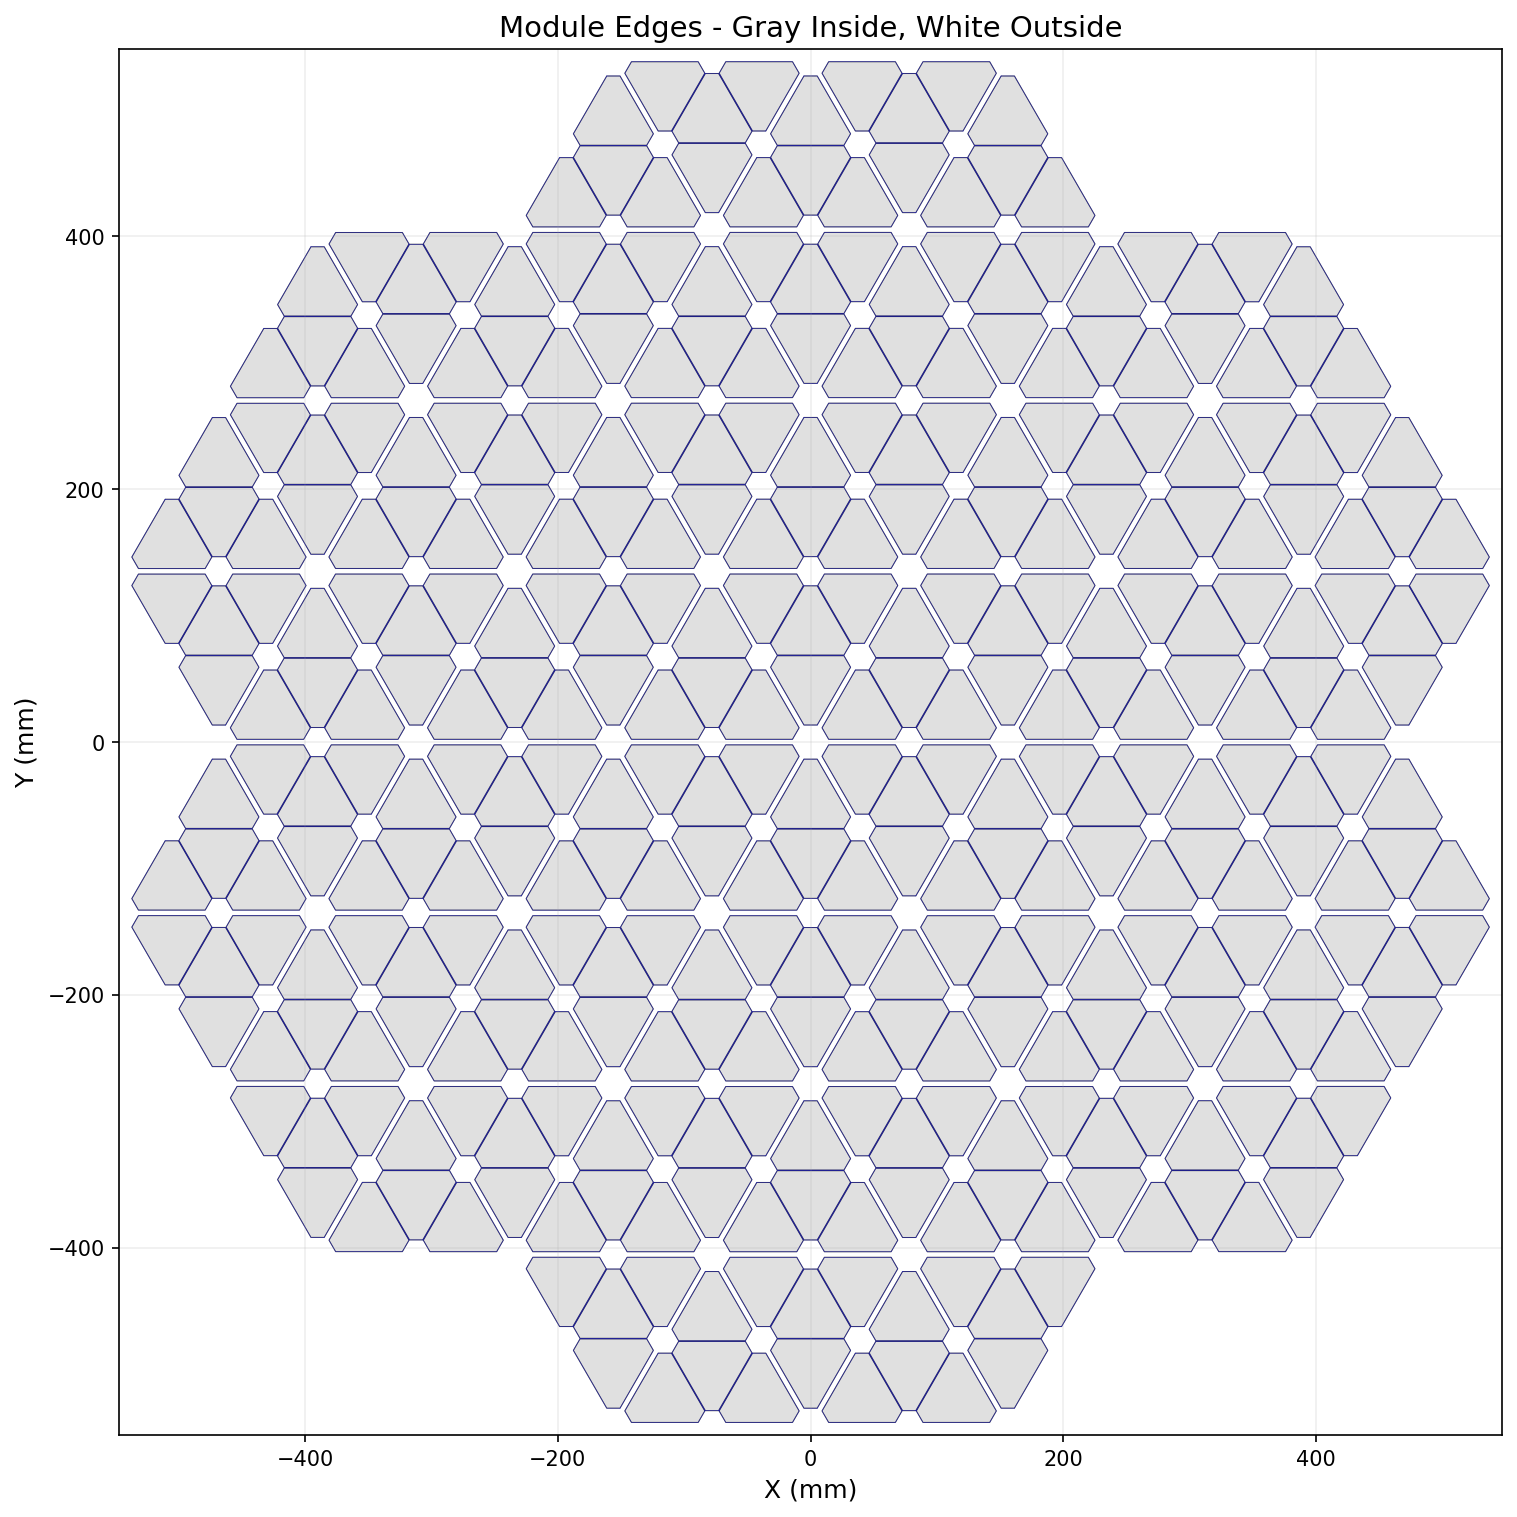

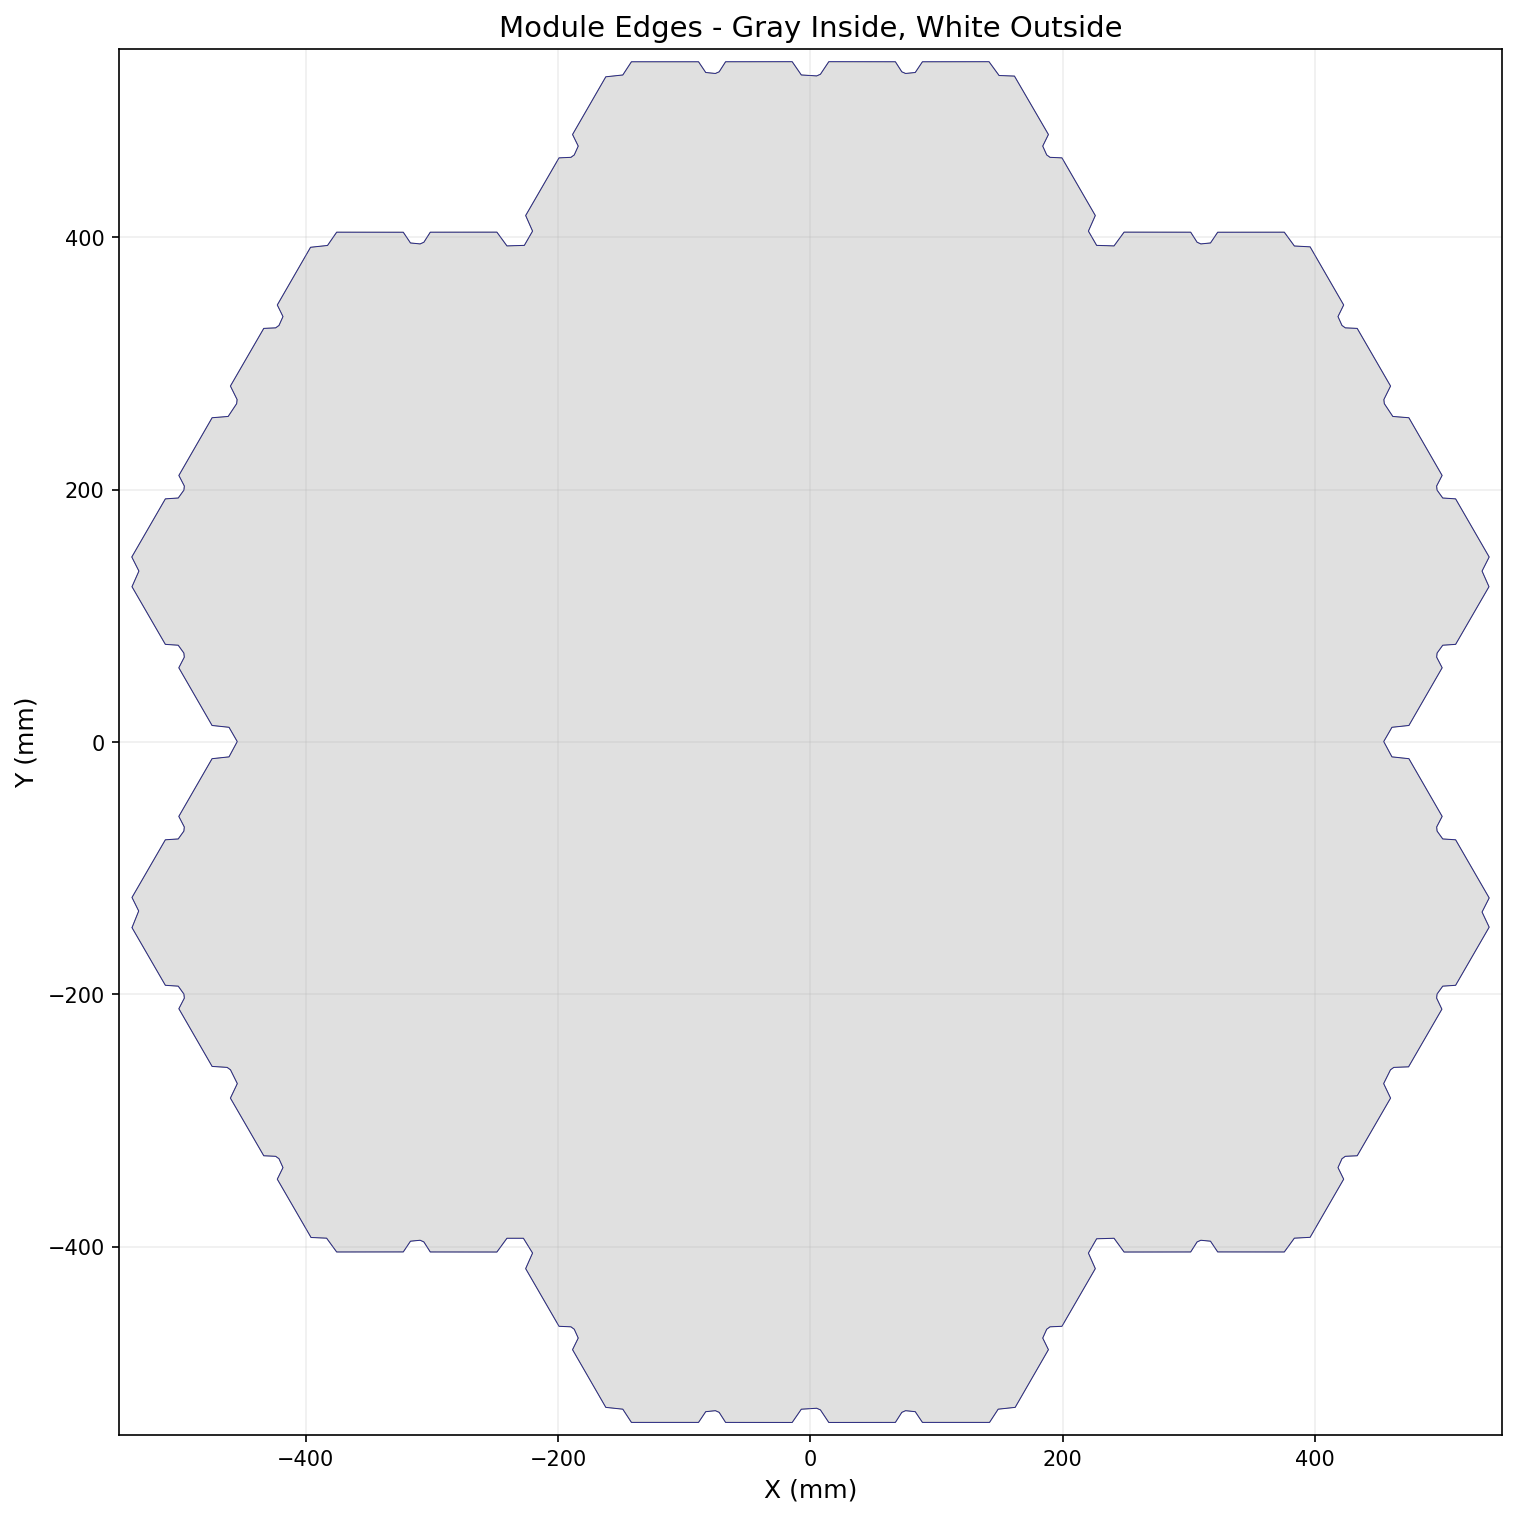

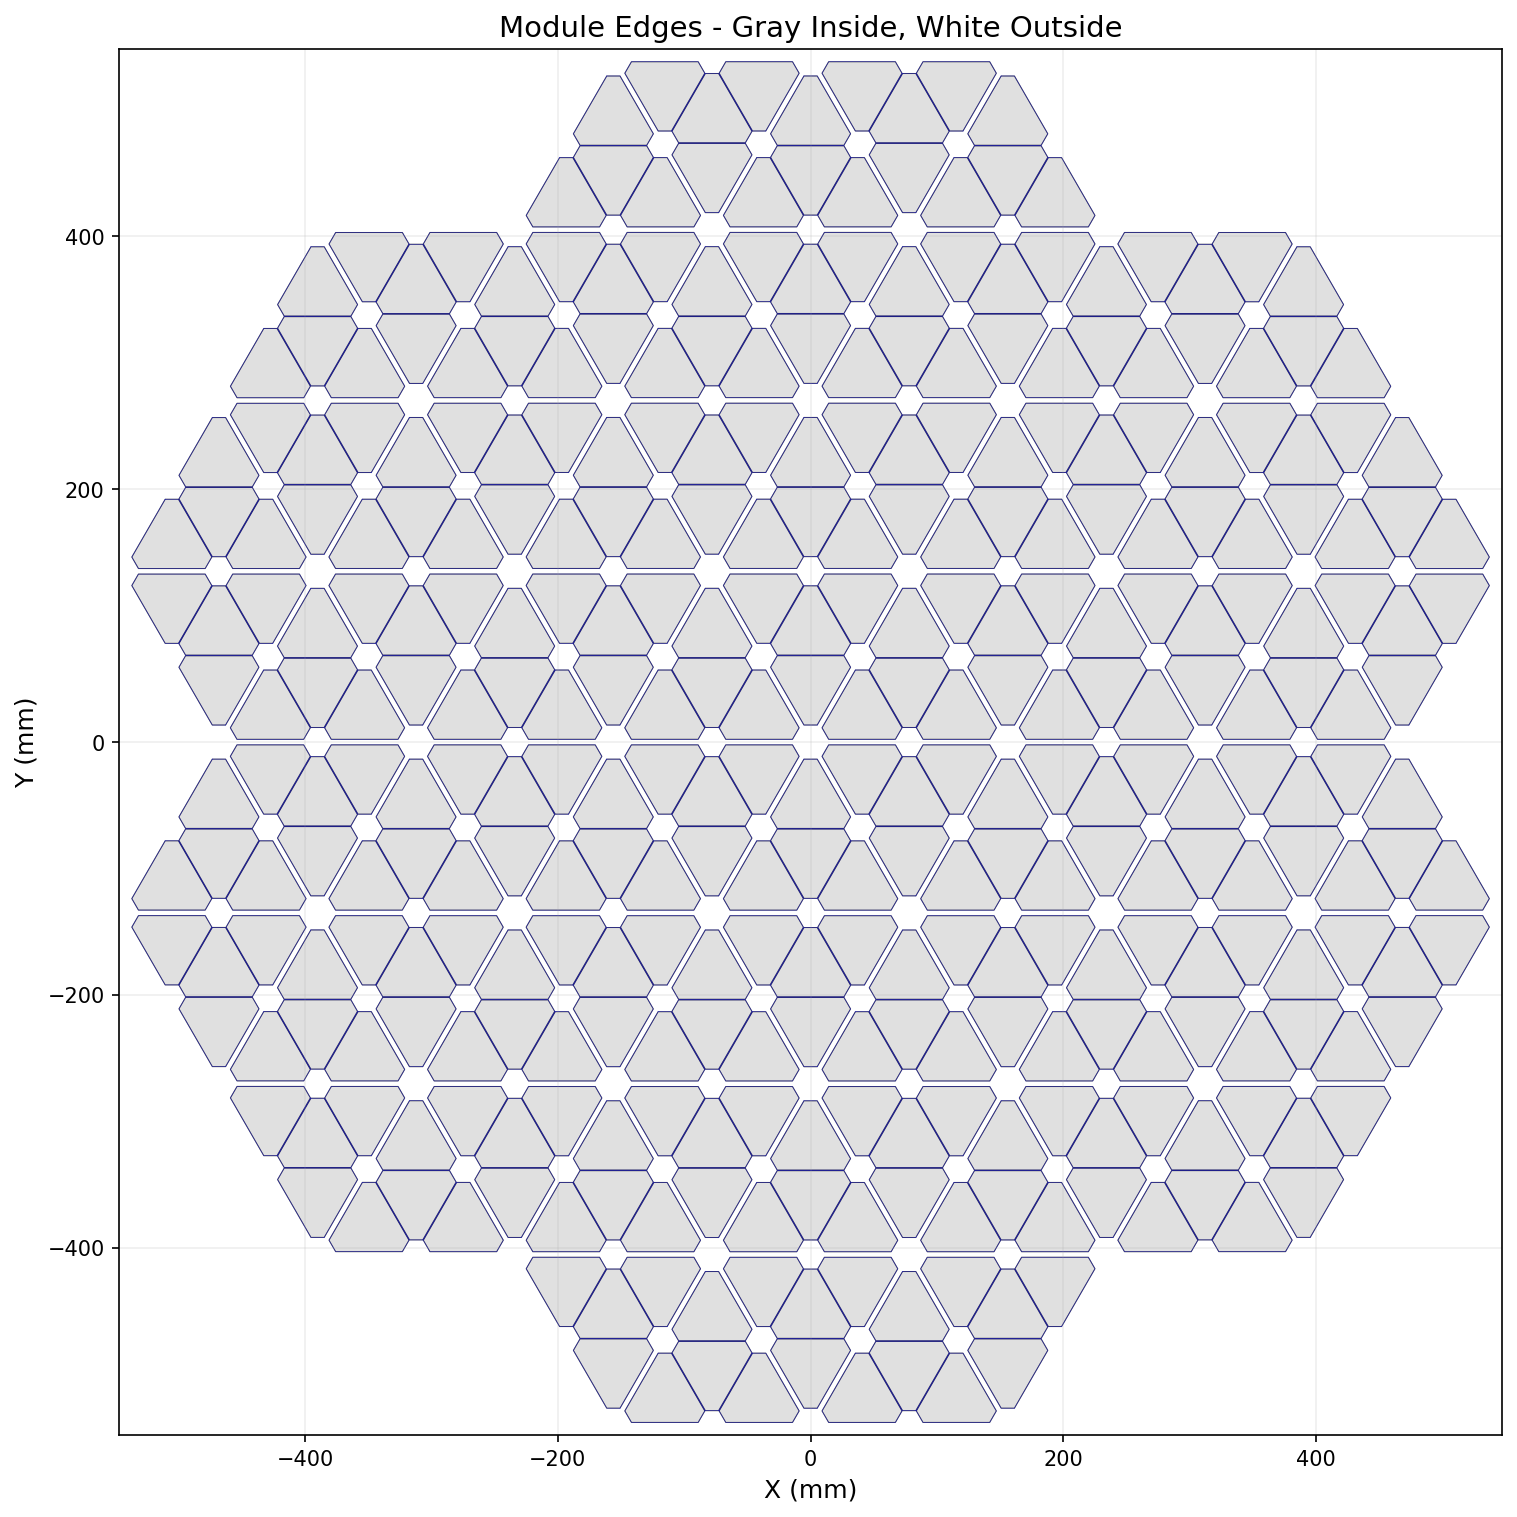

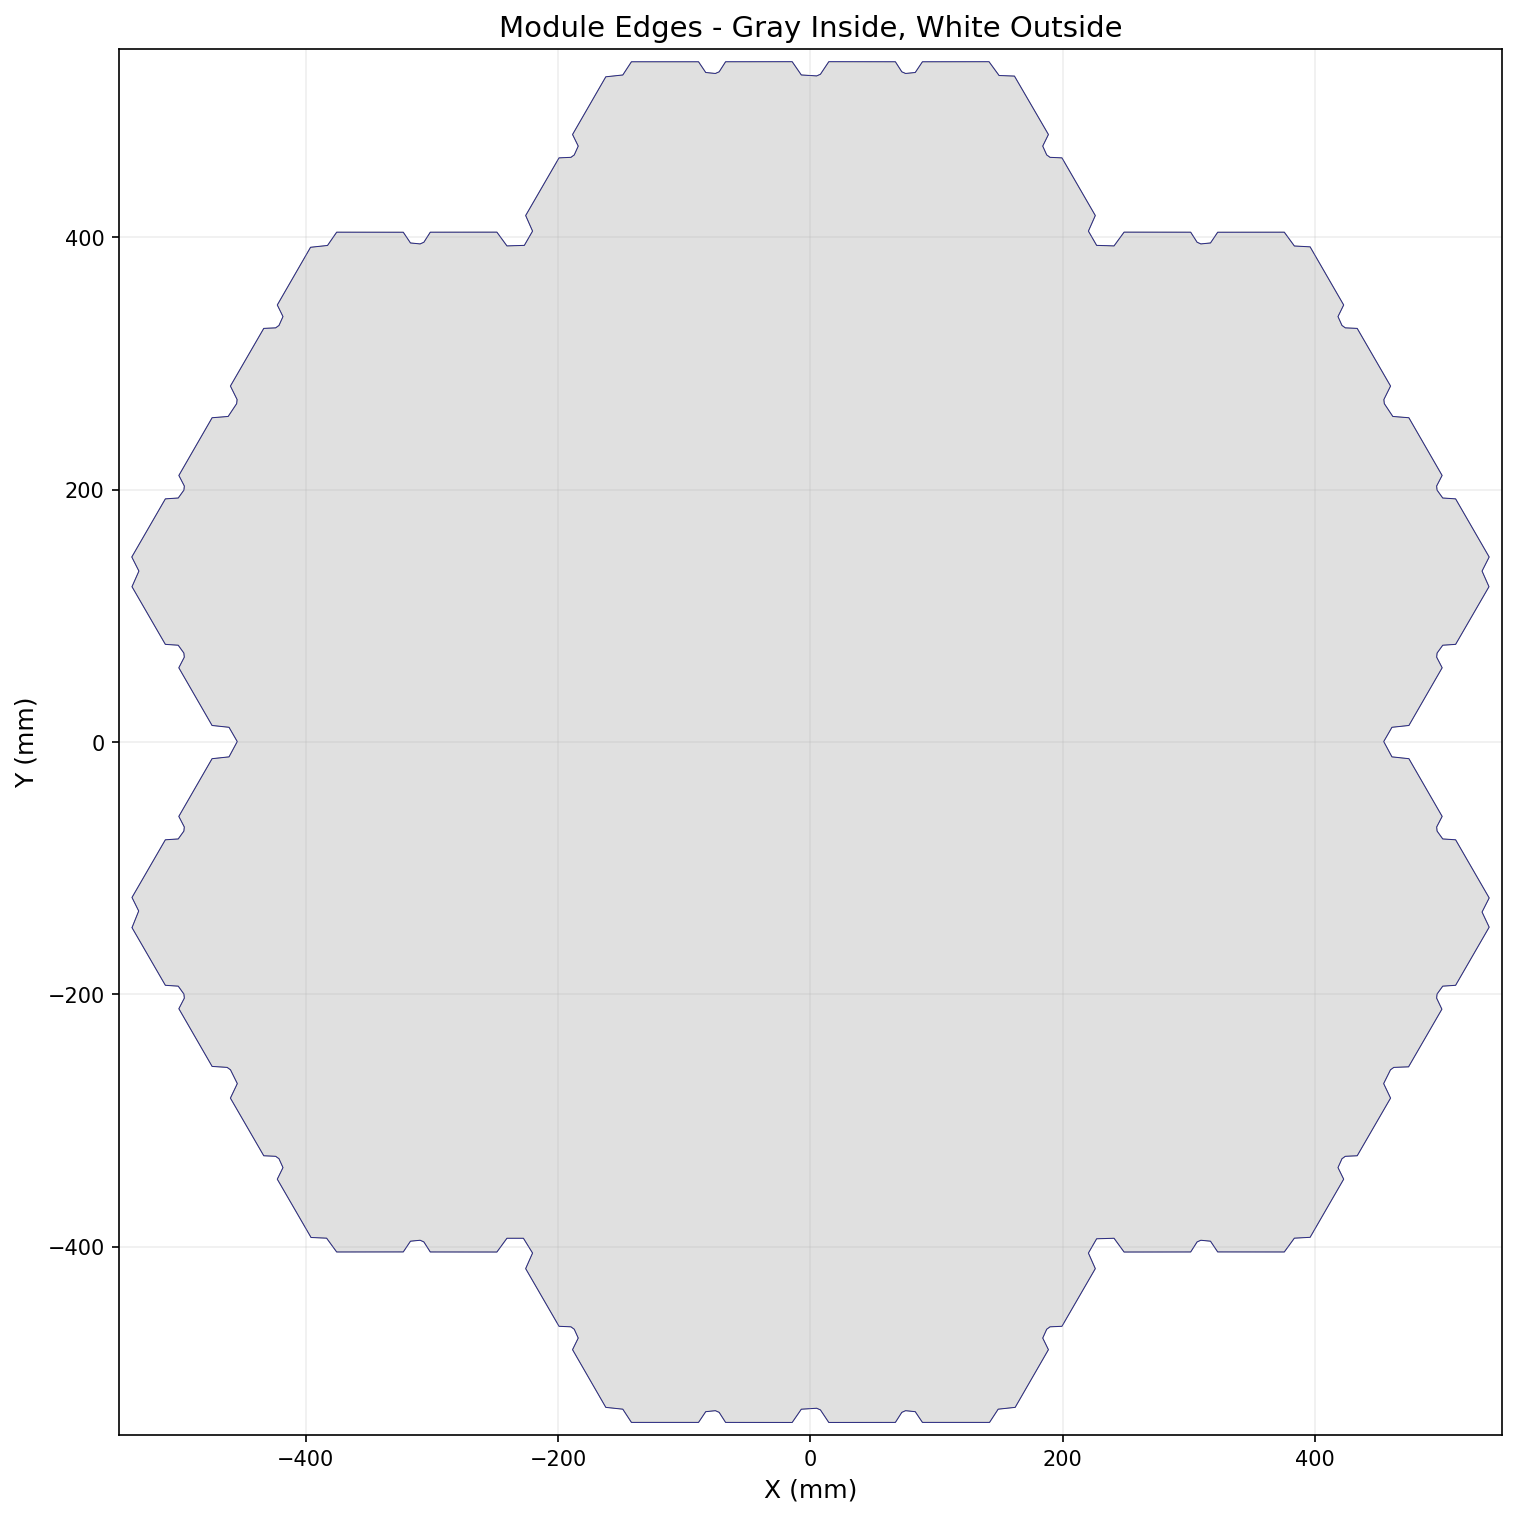

In [15]:
# =========================
# 修改后的保存 segments → PLY（面格式）
# =========================
def save_segments_to_ply(segments, filename):
    """
    将 segments 保存为 PLY 文件（顶点+面格式）
    使用 polygonize 自动识别闭合区域并创建面
    """
    # 从 segments 重建线段
    lines = []
    all_vertices = []
    
    for seg in segments:
        pts = seg.T  # (n, 2)
        if len(pts) > 1:
            # 添加线段
            lines.append(LineString(pts))
            # 收集所有顶点
            all_vertices.extend(pts)
    
    if not lines:
        print("⚠️ 没有有效的线段")
        return
    
    # 使用 polygonize 识别闭合区域
    multi_line = MultiLineString(lines)
    polygons = list(polygonize(multi_line))
    
    # 如果 polygonize 失败，使用 buffer 方法
    if not polygons:
        print("Polygonize 失败，尝试 buffer 方法...")
        merged = unary_union(multi_line)
        buffered = merged.buffer(1.0, resolution=8)
        
        if isinstance(buffered, ShapelyPolygon):
            polygons = [buffered]
        elif isinstance(buffered, MultiPolygon):
            polygons = list(buffered.geoms)
    
    # 收集所有多边形顶点并建立面索引
    all_verts = []
    faces = []
    vertex_map = {}  # 用于去重顶点
    
    for polygon in polygons:
        if hasattr(polygon, 'exterior'):
            exterior_coords = list(polygon.exterior.coords)[:-1]  # 去除重复的闭合点
            
            # 处理每个顶点
            face_indices = []
            for coord in exterior_coords:
                coord_tuple = (round(coord[0], 6), round(coord[1], 6))
                
                if coord_tuple not in vertex_map:
                    vertex_map[coord_tuple] = len(all_verts)
                    all_verts.append([coord[0], coord[1], 0.0])  # x, y, z
                
                face_indices.append(vertex_map[coord_tuple])
            
            if len(face_indices) >= 3:
                faces.append(face_indices)
    
    if not faces:
        print("⚠️ 未能创建任何面")
        return
    
    # 写入 PLY 文件
    vertices_array = np.array(all_verts)
    
    with open(filename, 'w') as f:
        f.write("ply\n")
        f.write("format ascii 1.0\n")
        f.write(f"element vertex {len(vertices_array)}\n")
        f.write("property float x\n")
        f.write("property float y\n")
        f.write("property float z\n")
        f.write(f"element face {len(faces)}\n")
        f.write("property list uchar int vertex_indices\n")
        f.write("end_header\n")
        
        # 写入顶点
        for v in vertices_array:
            f.write(f"{v[0]} {v[1]} {v[2]}\n")
        
        # 写入面
        for face in faces:
            f.write(f"{len(face)} {' '.join(map(str, face))}\n")
    
    print(f"✅ 保存 PLY: {len(vertices_array)} 顶点, {len(faces)} 面 → {filename}")


# =========================
# 修改后的保存 boundary → PLY（面格式）
# =========================
def save_boundary_to_ply(boundary, filename):
    """
    将外边界保存为 PLY 文件（顶点+面格式）
    boundary: (n, 2) numpy 数组，有序的边界坐标
    """
    n = len(boundary)
    
    if n < 3:
        print("⚠️ 边界点数不足")
        return
    
    # 创建顶点（添加 z=0）
    vertices = np.hstack([boundary[:, :2], np.zeros((n, 1))])
    
    # 创建面（单个面包含所有边界点）
    face = list(range(n))
    
    # 写入 PLY 文件
    with open(filename, 'w') as f:
        f.write("ply\n")
        f.write("format ascii 1.0\n")
        f.write(f"element vertex {n}\n")
        f.write("property float x\n")
        f.write("property float y\n")
        f.write("property float z\n")
        f.write(f"element face 1\n")
        f.write("property list uchar int vertex_indices\n")
        f.write("end_header\n")
        
        # 写入顶点
        for v in vertices:
            f.write(f"{v[0]} {v[1]} {v[2]}\n")
        
        # 写入面
        f.write(f"{n} {' '.join(map(str, face))}\n")
    
    print(f"✅ 保存边界 PLY: {n} 顶点, 1 面 → {filename}")


def get_outer_boundary(segments, buffer_distance=5.0, simplify_tolerance=1.0):
    """
    从所有 segments 中提取外边界
    
    参数:
    - segments: 线段列表 [[[x,...], [y,...]], ...]
    - buffer_distance: 缓冲距离，用于闭合微小间隙
    - simplify_tolerance: 简化容差，减少边界点数
    """
    lines = []
    
    # 收集所有线段
    print("收集线段...")
    for i, seg in enumerate(segments):
        pts = seg.T  # (n, 2)
        if len(pts) > 1:
            # 确保线段方向一致，去掉重复点
            clean_pts = [pts[0]]
            for j in range(1, len(pts)):
                if np.linalg.norm(pts[j] - pts[j-1]) > 1e-6:  # 过滤重复点
                    clean_pts.append(pts[j])
            if len(clean_pts) > 1:
                lines.append(LineString(clean_pts))
    
    if not lines:
        raise RuntimeError("❌ 没有有效的线段")
    
    print(f"总线段数: {len(lines)}")
    
    # 方法1: 合并线段并提取外轮廓
    try:
        print("尝试方法1: 合并线段提取轮廓...")
        
        # 将所有线段合并成一个几何体
        multi_line = MultiLineString(lines)
        
        # 合并所有线段
        merged = unary_union(multi_line)
        print(f"合并后类型: {type(merged).__name__}")
        
        # 使用 buffer 技巧闭合微小间隙
        # 先向外扩张，再向内收缩
        buffered = merged.buffer(buffer_distance, resolution=8)
        contracted = buffered.buffer(-buffer_distance * 0.8, resolution=8)
        
        # 如果收缩后为空，尝试不同的buffer参数
        if contracted.is_empty:
            print("Buffer收缩后为空，调整参数...")
            buffered = merged.buffer(buffer_distance * 0.5, resolution=8)
            contracted = buffered.buffer(-buffer_distance * 0.4, resolution=8)
        
        # 尝试提取边界
        if hasattr(contracted, 'exterior'):
            # 如果结果是多边形
            boundary = contracted.exterior
            coords = np.array(boundary.coords)
            print(f"✅ 方法1成功: {len(coords)} 个边界点")
            
            # 简化边界
            if simplify_tolerance > 0:
                simplified = boundary.simplify(simplify_tolerance)
                coords = np.array(simplified.coords)
                print(f"简化后: {len(coords)} 个边界点")
            
            return coords
            
        elif hasattr(contracted, 'geoms'):
            # 如果是多个几何体，取面积最大的
            polygons = [g for g in contracted.geoms if hasattr(g, 'exterior')]
            if polygons:
                largest = max(polygons, key=lambda p: p.area)
                boundary = largest.exterior
                coords = np.array(boundary.coords)
                print(f"✅ 方法1成功(多几何体): {len(coords)} 个边界点，面积: {largest.area:.2f}")
                return coords
                
    except Exception as e:
        print(f"方法1失败: {e}")
    
    # 方法2: 凸包方法（确保至少能得到一个边界）
    try:
        print("尝试方法2: 凸包方法...")
        
        # 收集所有点
        all_points = []
        for line in lines:
            all_points.extend(line.coords)
        
        points = MultiPoint(all_points)
        convex_hull = points.convex_hull
        
        if hasattr(convex_hull, 'exterior'):
            boundary = convex_hull.exterior
            coords = np.array(boundary.coords)
            print(f"✅ 方法2成功(凸包): {len(coords)} 个边界点，面积: {convex_hull.area:.2f}")
            return coords
            
    except Exception as e:
        print(f"方法2失败: {e}")
    
    # 方法3: 直接连接最外围的点
    try:
        print("尝试方法3: 极值点方法...")
        
        all_points = []
        for line in lines:
            all_points.extend(line.coords)
        
        points_array = np.array(all_points)
        
        # 找到四个方向的最远点
        leftmost = points_array[points_array[:, 0].argmin()]
        rightmost = points_array[points_array[:, 0].argmax()]
        bottommost = points_array[points_array[:, 1].argmin()]
        topmost = points_array[points_array[:, 1].argmax()]
        
        # 创建一个包围所有点的矩形
        x_min, y_min = points_array[:, 0].min(), points_array[:, 1].min()
        x_max, y_max = points_array[:, 0].max(), points_array[:, 1].max()
        
        # 扩展一点边界
        margin = 10
        boundary_coords = np.array([
            [x_min - margin, y_min - margin],
            [x_max + margin, y_min - margin],
            [x_max + margin, y_max + margin],
            [x_min - margin, y_max + margin],
            [x_min - margin, y_min - margin]
        ])
        
        print(f"✅ 方法3成功(包围盒): {len(boundary_coords)} 个边界点")
        return boundary_coords
        
    except Exception as e:
        print(f"方法3失败: {e}")
    
    raise RuntimeError("❌ 所有方法都无法提取外边界")
# =========================
# 修改 read_ply 以支持面格式
# =========================
def read_ply(filename):
    """
    读取 PLY 文件，自动适配顶点+面或顶点+边格式
    返回 vertices, faces (面格式优先)
    """
    vertices = []
    faces = []
    edges = []
    
    with open(filename, 'r') as f:
        lines = f.readlines()
    
    # 解析 header
    i = 0
    n_vertices = 0
    n_faces = 0
    n_edges = 0
    has_faces = False
    has_edges = False
    
    while i < len(lines):
        line = lines[i].strip()
        if line.startswith('element vertex'):
            n_vertices = int(line.split()[-1])
        elif line.startswith('element face'):
            n_faces = int(line.split()[-1])
            has_faces = True
        elif line.startswith('element edge'):
            n_edges = int(line.split()[-1])
            has_edges = True
        elif line == 'end_header':
            i += 1
            break
        i += 1
    
    # 读取顶点
    for j in range(n_vertices):
        parts = lines[i + j].strip().split()
        vertices.append([float(parts[0]), float(parts[1]), float(parts[2])])
    
    # 读取面或边
    if has_faces:
        for j in range(n_faces):
            parts = list(map(int, lines[i + n_vertices + j].strip().split()))
            n_indices = parts[0]  # 面的顶点数
            face_indices = parts[1:n_indices + 1]
            faces.append(face_indices)
    elif has_edges:
        for j in range(n_edges):
            parts = lines[i + n_vertices + j].strip().split()
            edges.append([int(parts[0]), int(parts[1])])
    
    vertices = np.array(vertices)
    
    # 如果只有边没有面，尝试转换为面格式
    if has_edges and not has_faces:
        # 返回时也包含边信息
        return vertices, np.array(edges)
    
    return vertices, np.array(faces)


# =========================
# 简化的 read_ply_as_multipolygon
# =========================
def read_ply_as_multipolygon(filename):
    """
    读取 PLY 文件并返回 MultiPolygon（适用于面格式）
    """
    try:
        vertices, faces = read_ply(filename)
        
        # 检查是否为面格式
        if len(faces) > 0 and isinstance(faces[0], (list, np.ndarray)) and len(faces[0]) >= 3:
            # 面格式
            polygons = []
            for face in faces:
                face_vertices = vertices[face][:, :2]
                if len(face_vertices) >= 3:
                    poly = ShapelyPolygon(face_vertices)
                    if poly.is_valid and poly.area > 1e-6:
                        polygons.append(poly)
            
            if polygons:
                return MultiPolygon(polygons)
            else:
                return MultiPolygon()
        else:
            # 边格式，需要转换
            print("PLY 文件为边格式，正在转换为面格式...")
            # 这里可以调用之前的转换逻辑
            # ...
            return MultiPolygon()
    except Exception as e:
        print(f"读取 PLY 失败: {e}")
        return MultiPolygon()
def get_dxf_points(fname):
    doc = ezdxf.readfile(fname)
    msp = doc.modelspace()
    segments = []
    for e in msp:
        with e.points() as points: # [(x, y, start_width, end_width, bulge), ...]
            #print(e, len(points))
            xy = np.array(points).T[:2] # (2, npoints)
            segments.append(xy)
    return segments # [[[x, ...], [y, ...]], ...]
# =========================
# 可视化 PLY 验证
# =========================
def plot_ply_verification(segments_ply="segments.ply", boundary_ply="outer_boundary.ply"):
    """
    读取保存的 PLY 文件并可视化：
    - 外轮廓（红色边框）
    - 内部区域（灰色填充）
    - 内部线段（深灰色线条）
    """
    # 读取边界
    boundary_verts, boundary_edges = read_ply(boundary_ply)
    
    # 读取 segments
    segments_verts, segments_edges = read_ply(segments_ply)
    
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # 1. 内部区域灰色填充（基于外边界）
    from matplotlib.patches import Polygon
    polygon = Polygon(boundary_verts[:, :2], 
                      closed=True, 
                      facecolor='lightgray', 
                      edgecolor='none',
                      alpha=0.5,
                      zorder=1)
    ax.add_patch(polygon)
    
    # 2. 绘制内部线段（深灰色）
    for edge in segments_edges:
        v1 = segments_verts[edge[0], :2]
        v2 = segments_verts[edge[1], :2]
        ax.plot([v1[0], v2[0]], [v1[1], v2[1]], 
                color='dimgray', linewidth=0.8, alpha=0.7, zorder=2)
    
    # 3. 绘制外边界（红色粗线）
    for edge in boundary_edges:
        v1 = boundary_verts[edge[0], :2]
        v2 = boundary_verts[edge[1], :2]
        ax.plot([v1[0], v2[0]], [v1[1], v2[1]], 
                color='red', linewidth=2.5, zorder=3)
    
    # 4. 标记顶点（可选，用于调试）
    # ax.scatter(boundary_verts[:, 0], boundary_verts[:, 1], 
    #           c='red', s=30, zorder=4, label='Boundary vertices')
    # ax.scatter(segments_verts[:, 0], segments_verts[:, 1], 
    #           c='blue', s=10, zorder=5, label='Segment vertices')
    
    # 设置图形属性
    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('PLY out line (red)')
    ax.grid(True, alpha=0.3)
    
    # 自动调整显示范围
    all_verts = np.vstack([boundary_verts[:, :2], segments_verts[:, :2]])
    x_min, y_min = all_verts.min(axis=0) - 10
    x_max, y_max = all_verts.max(axis=0) + 10
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    
    plt.tight_layout()
    plt.show()
    
    # 打印统计信息
    print(f"边界顶点数: {len(boundary_verts)}")
    print(f"边界边数: {len(boundary_edges)}")
    print(f"内部顶点数: {len(segments_verts)}")
    print(f"内部边数: {len(segments_edges)}")
    print(f"边界是否闭合: {boundary_edges[0][0] == boundary_edges[-1][1]}")
# =========================
# 主程序中使用（保持不变）
# =========================
if __name__=='__main__':

    folder_path = '/home/hmf/work/FA_test/MUST_FP/2026.04.15/'

    # 获取所有子文件夹名
    subfolders = [name for name in os.listdir(folder_path) 
                if os.path.isdir(os.path.join(folder_path, name))]
    
    for name in subfolders:
        dname = os.path.join(folder_path, name)
        # print( glob.glob(f'{dname}/2026-04-2*.dxf')[0])
        fname = glob.glob(f'{dname}/2026-04-27*.dxf')[0]
        segments = get_dxf_points(fname)

        print("保存 segments.ply...")
        save_segments_to_ply(segments[-336:], f"{dname}/segments.ply")

        print("提取外边界...")
        boundary = get_outer_boundary(segments[-336:])

        print("保存 outer_boundary.ply...")
        save_boundary_to_ply(boundary, f"{dname}/outer_boundary.ply")

        print("从 PLY 文件读取并验证...")
        # plot_ply_verification(f"{dname}/segments.ply", f"{dname}/outer_boundary.ply")
        plot_ply_with_fill(f"{dname}/segments.ply")
        plot_ply_with_fill(f"{dname}/outer_boundary.ply")


        print("完成！")

In [4]:
from shapely.geometry import Point
from shapely.ops import unary_union, polygonize, linemerge
from matplotlib.patches import Polygon as MPLPolygon
from matplotlib.collections import PatchCollection

def plot_segments_ply_with_fill(segments_ply="segments.ply", fill_color='lightgray', 
                                fill_alpha=0.5, edge_color='dimgray', edge_width=0.8):
    """
    读取 segments PLY 文件并绘制，内部区域用灰色填充
    
    参数:
    - segments_ply: PLY 文件路径
    - fill_color: 填充颜色
    - fill_alpha: 填充透明度
    - edge_color: 线段颜色
    - edge_width: 线段宽度
    """
    # 读取 PLY 文件
    vertices, edges = read_ply(segments_ply)
    
    print(f"读取到 {len(vertices)} 个顶点, {len(edges)} 条边")
    
    # 重建线段
    lines = []
    for edge in edges:
        v1 = vertices[edge[0], :2]
        v2 = vertices[edge[1], :2]
        lines.append(LineString([v1, v2]))
    
    # 尝试创建闭合区域用于填充
    fill_polygons = []
    
    try:
        # 方法1: 尝试合并线段并识别闭合区域
        print("尝试识别闭合区域...")
        multi_line = MultiLineString(lines)
        
        # 合并连通线段
        merged = linemerge(multi_line)
        
        # 处理合并结果
        if isinstance(merged, LineString):
            line_strings = [merged]
        elif isinstance(merged, MultiLineString):
            line_strings = list(merged.geoms)
        else:
            line_strings = []
        
        # 尝试从每条线段创建多边形
        for line in line_strings:
            if isinstance(line, LineString) and len(line.coords) >= 4:
                # 检查是否闭合
                start = Point(line.coords[0])
                end = Point(line.coords[-1])
                
                if start.distance(end) < 1.0:  # 认为是闭合的
                    try:
                        polygon = Polygon(line)
                        if polygon.is_valid and polygon.area > 10:  # 过滤太小的区域
                            fill_polygons.append(polygon)
                    except Exception as e:
                        print(f"创建多边形失败: {e}")
        
        # 如果没有找到闭合区域，尝试用 buffer 方法
        if not fill_polygons:
            print("尝试 buffer 方法创建填充区域...")
            buffered = multi_line.buffer(2.0, resolution=8)
            if isinstance(buffered, Polygon):
                fill_polygons.append(buffered)
            elif isinstance(buffered, MultiPolygon):
                fill_polygons.extend(list(buffered.geoms))
                
    except Exception as e:
        print(f"识别闭合区域失败: {e}")
        # 使用简单的矩形包围作为填充
        all_points = vertices[:, :2]
        x_min, y_min = all_points.min(axis=0)
        x_max, y_max = all_points.max(axis=0)
        margin = 5
        fill_polygons = [Polygon([
            (x_min - margin, y_min - margin),
            (x_max + margin, y_min - margin),
            (x_max + margin, y_max + margin),
            (x_min - margin, y_max + margin)
        ])]
    
    # 开始绘图
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # 1. 绘制填充区域（灰色）
    if fill_polygons:
        patches = []
        for poly in fill_polygons:
            if hasattr(poly, 'exterior'):
                exterior_coords = list(poly.exterior.coords)
                patch = MPLPolygon(exterior_coords, closed=True)
                patches.append(patch)
            elif hasattr(poly, 'geoms'):
                for sub_poly in poly.geoms:
                    if hasattr(sub_poly, 'exterior'):
                        exterior_coords = list(sub_poly.exterior.coords)
                        patch = MPLPolygon(exterior_coords, closed=True)
                        patches.append(patch)
        
        if patches:
            collection = PatchCollection(patches, 
                                       facecolor=fill_color, 
                                       edgecolor='none',
                                       alpha=fill_alpha,
                                       zorder=1)
            ax.add_collection(collection)
            print(f"添加了 {len(patches)} 个填充区域")
    
    # 2. 绘制所有线段（深灰色）
    for edge in edges:
        v1 = vertices[edge[0], :2]
        v2 = vertices[edge[1], :2]
        ax.plot([v1[0], v2[0]], [v1[1], v2[1]], 
                color=edge_color, linewidth=edge_width, 
                alpha=0.8, zorder=2)
    
    # 3. 标记顶点（可选）
    # ax.scatter(vertices[:, 0], vertices[:, 1], c='blue', s=5, zorder=3, alpha=0.5)
    
    # 设置图形属性
    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'Segments PLY\n({len(vertices)} top, {len(edges)} line, {len(fill_polygons)} region)')
    ax.grid(True, alpha=0.3)
    
    # 自动调整显示范围
    if len(vertices) > 0:
        x_min, y_min = vertices[:, :2].min(axis=0) - 20
        x_max, y_max = vertices[:, :2].max(axis=0) + 20
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
    
    plt.tight_layout()
    plt.show()
    
    # 打印统计信息
    print(f"\n绘图完成:")
    print(f"  - 顶点数: {len(vertices)}")
    print(f"  - 边数: {len(edges)}")
    print(f"  - 填充区域数: {len(fill_polygons)}")
    if fill_polygons:
        total_area = sum(poly.area for poly in fill_polygons)
        print(f"  - 总填充面积: {total_area:.2f}")


# 如果只想简单绘制，不需要自动识别闭合区域，可以用这个简化版
def plot_segments_ply_simple(segments_ply="segments.ply", fill_color='lightgray', 
                            fill_alpha=0.3, edge_color='dimgray', edge_width=0.8):
    """
    简化版：读取 segments PLY 并使用包围盒作为灰色填充
    """
    # 读取 PLY 文件
    vertices, edges = read_ply(segments_ply)
    
    print(f"read {len(vertices)} , {len(edges)} line")
    
    # 创建包围盒作为填充区域
    all_points = vertices[:, :2]
    x_min, y_min = all_points.min(axis=0)
    x_max, y_max = all_points.max(axis=0)
    margin = 10
    
    fill_polygon = Polygon([
        (x_min - margin, y_min - margin),
        (x_max + margin, y_min - margin),
        (x_max + margin, y_max + margin),
        (x_min - margin, y_max + margin)
    ])
    
    # 开始绘图
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # 1. 绘制填充区域（灰色）
    exterior_coords = list(fill_polygon.exterior.coords)
    patch = MPLPolygon(exterior_coords, closed=True)
    collection = PatchCollection([patch], 
                               facecolor=fill_color, 
                               edgecolor='none',
                               alpha=fill_alpha,
                               zorder=1)
    ax.add_collection(collection)
    
    # 2. 绘制所有线段（深灰色）
    for edge in edges:
        v1 = vertices[edge[0], :2]
        v2 = vertices[edge[1], :2]
        ax.plot([v1[0], v2[0]], [v1[1], v2[1]], 
                color=edge_color, linewidth=edge_width, 
                alpha=0.8, zorder=2)
    
    # 设置图形属性
    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'module region')
    ax.grid(True, alpha=0.3)
    
    # 自动调整显示范围
    if len(vertices) > 0:
        x_min, y_min = vertices[:, :2].min(axis=0) - 20
        x_max, y_max = vertices[:, :2].max(axis=0) + 20
        ax.set_xlim(x_min, y_max)
        ax.set_ylim(y_min, y_max)
    
    plt.tight_layout()
    plt.show()


# 在主程序中使用
if __name__=='__main__':
    
    folder_path = '/home/hmf/work/FA_test/MUST_FP/2026.04.15/'

    # 获取所有子文件夹名
    subfolders = [name for name in os.listdir(folder_path) 
                if os.path.isdir(os.path.join(folder_path, name))]
    for dname in subfolders[2:3]:
        dname = os.path.join(folder_path, dname)
        # 绘制 segments PLY 文件
        print("绘制 segments PLY 文件...")
        plot_segments_ply_with_fill(f"{dname}/segments.ply")  # 使用智能填充
        # 或使用简化版
        # plot_segments_ply_simple("segments.ply")  # 使用包围盒填充

NameError: name 'os' is not defined

In [ ]:
import sys
sys.path.append('/home/hmf/work/software/must_fbautil-main/python/')
from utils import *
import ezdxf
import glob
def plotconfig_xy(ax=None):
    if ax is None: ax = plt.gca()
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_aspect('equal')
    ax.figure.tight_layout()
def get_dxf_points(fname):
    doc = ezdxf.readfile(fname)
    msp = doc.modelspace()
    segments = []
    for e in msp:
        with e.points() as points: # [(x, y, start_width, end_width, bulge), ...]
            #print(e, len(points))
            xy = np.array(points).T[:2] # (2, npoints)
            segments.append(xy)
    return segments # [[[x, ...], [y, ...]], ...]

from steputils import p21
def get_step_points(fname):
    pass

def plot_segments(segments):
    fig, ax = plt.subplots(figsize=(10, 10))
    for xy in segments:
        ax.plot(*xy, '-')
        #ax.plot(*xy[:, 0], 'ks')
        #ax.plot(*xy[:, 1], 'rs')
    plotconfig_xy(ax)
    plt.show()

# if __name__=='__main__':
#     actions = ['plot_dxf']
#     if 'plot_dxf' in actions:
#         fname = glob.glob('/home/hmf/work/FA_test/MUST_FP/2026.04.15/Framed-GlobalGap4.4mm-NoModuleWalls/2026-04-27*.dxf')[0]
#         segments = get_dxf_points(fname)
        

#     if 'plot_step' in actions:
#         fname = '/home/hmf/work/software/must_fbautil-main/data/focalplane/coordinate_system_and_3D_model/Polygonal_model_current_prototype.STEP'

# plot_segments(segments[-10:])

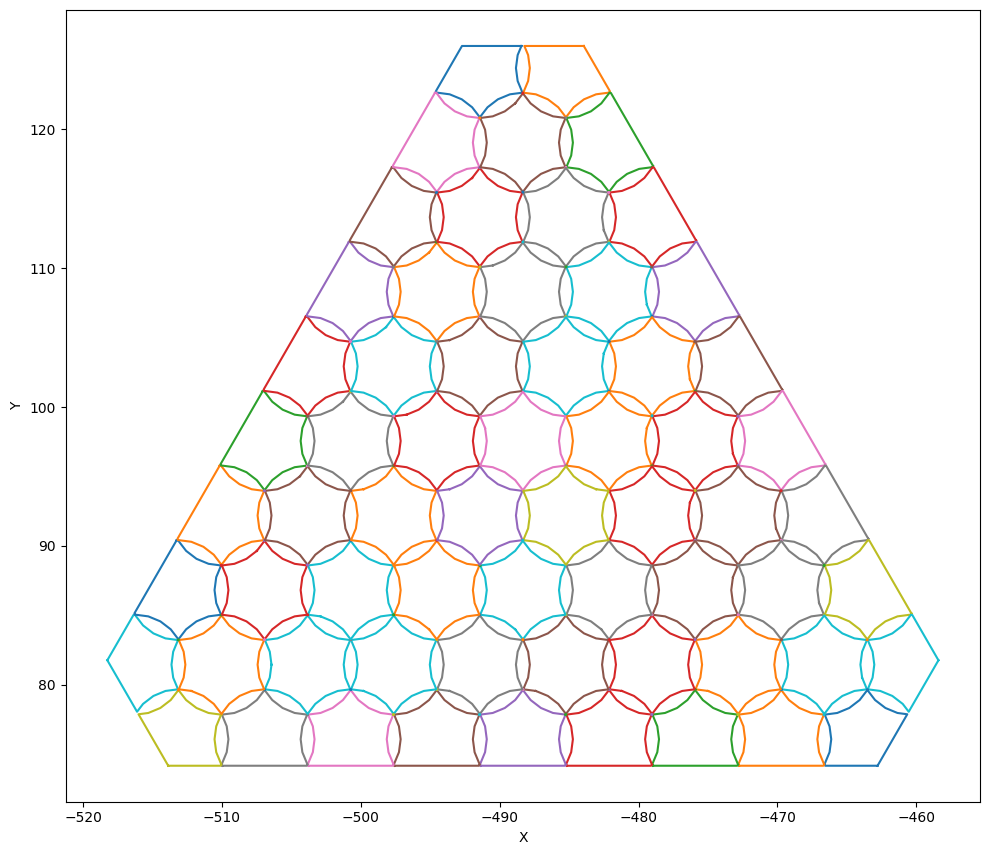

In [10]:
import sys
sys.path.append('/home/hmf/work/software/must_fbautil-main/python/')
from utils import *
import ezdxf
import glob
import numpy as np
def plotconfig_xy(ax=None):
    if ax is None: ax = plt.gca()
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_aspect('equal')
    ax.figure.tight_layout()
def get_dxf_points(fname):
    doc = ezdxf.readfile(fname)
    msp = doc.modelspace()
    segments = []
    for e in msp:
        with e.points() as points: # [(x, y, start_width, end_width, bulge), ...]
            #print(e, len(points))
            xy = np.array(points).T[:2] # (2, npoints)
            segments.append(xy)
    return segments # [[[x, ...], [y, ...]], ...]

from steputils import p21
def get_step_points(fname):
    pass

def plot_segments(segments):
    fig, ax = plt.subplots(figsize=(10, 10))
    for xy in segments:
        ax.plot(*xy, '-')
        #ax.plot(*xy[:, 0], 'ks')
        #ax.plot(*xy[:, 1], 'rs')
    plotconfig_xy(ax)
    plt.show()

if __name__=='__main__':
    actions = ['plot_dxf']
    if 'plot_dxf' in actions:
        fname = glob.glob('/home/hmf/work/FA_test/MUST_FP/2026.04.15/Framed-GlobalGap4.4mm-ModuleWalls/2026-04-27*.dxf')[0]
        segments = get_dxf_points(fname)
        

    if 'plot_step' in actions:
        fname = '/home/hmf/work/software/must_fbautil-main/data/focalplane/coordinate_system_and_3D_model/Polygonal_model_current_prototype.STEP'

# plot_segments(segments[:63])
plot_segments(segments[:150])

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pickle
from matplotlib.ticker import FuncFormatter

def plot_all_results_comparison(all_results, save_dir="/home/hmf/work/FA_test/results/completeness_curves/"):
    """
    绘制 all_results 的比较图
    
    参数:
    - all_results: 包含所有结果的字典
    - save_dir: 保存图片的目录
    """
    
    # 提取所有唯一的 density 和 run_time
    densities = sorted(all_results.keys())
    
    # 获取所有 run_times（从第一个 density 中提取）
    run_times = []
    if densities:
        run_times = list(all_results[densities[0]].keys())
    
    # 提取 ply_base 信息
    ply_bases = {}
    for run_time in run_times:
        if densities and run_time in all_results[densities[0]]:
            ply_bases[run_time] = all_results[densities[0]][run_time].get('plybase', run_time[:16])
    
    # 创建图形
    fig = plt.figure(figsize=(20, 12))
    
    # =========================
    # 图1: 比较不同 target density
    # =========================
    ax1 = plt.subplot(2, 2, 1)
    plot_density_comparison(ax1, all_results, run_times[0] if run_times else None)
    
    ax2 = plt.subplot(2, 2, 2)
    plot_density_comparison(ax2, all_results, run_times[1] if len(run_times) > 1 else None)
    
    # =========================
    # 图2: 比较不同 ply_base
    # =========================
    ax3 = plt.subplot(2, 1, 2)
    plot_plybase_comparison(ax3, all_results, densities[-1] if densities else None)
    
    plt.tight_layout()
    
    # 保存图片
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, "completeness_comparison_all.png")
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    print(f"✅ 对比图保存到: {save_path}")
    plt.show()
    
    # =========================
    # 额外：详细对比图
    # =========================
    fig2, axes = plt.subplots(2, 2, figsize=(18, 14))
    
    # 左上：所有 density 在一个 run 下的对比
    ax = axes[0, 0]
    for density in densities:
        if run_times[0] in all_results[density]:
            com_list = all_results[density][run_times[0]]['completeness']
            iterations = range(1, len(com_list) + 1)
            overall_vals = extract_overall_completeness(com_list)
            ax.plot(iterations, overall_vals, '-o', linewidth=2, label=f'Density {density}', markersize=4)
    ax.set_xlabel('Number of FA Iterations')
    ax.set_ylabel('Overall Completeness')
    ax.set_title(f'Density Comparison - Run: {run_times[0][:16]}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])
    
    # 右上：所有 ply_base 在一个 density 下的对比
    ax = axes[0, 1]
    target_density = densities[-1]  # 使用最大 density
    for run_time in run_times:
        if target_density in all_results and run_time in all_results[target_density]:
            com_list = all_results[target_density][run_time]['completeness']
            iterations = range(1, len(com_list) + 1)
            overall_vals = extract_overall_completeness(com_list)
            label = ply_bases.get(run_time, run_time[:16])
            ax.plot(iterations, overall_vals, '-o', linewidth=2, label=label, markersize=4)
    ax.set_xlabel('Number of FA Iterations')
    ax.set_ylabel('Overall Completeness')
    ax.set_title(f'PLY Base Comparison - Density: {target_density}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])
    
    # 左下：不同 density 的最终 completeness 柱状图
    ax = axes[1, 0]
    plot_final_completeness_bars(ax, all_results, run_times, densities, ply_bases)
    
    # 右下：不同 run 的 completeness 收敛速度对比
    ax = axes[1, 1]
    plot_convergence_speed(ax, all_results, densities, run_times, ply_bases)
    
    plt.tight_layout()
    
    save_path2 = os.path.join(save_dir, "completeness_detailed_comparison.png")
    plt.savefig(save_path2, dpi=150, bbox_inches='tight')
    print(f"✅ 详细对比图保存到: {save_path2}")
    plt.show()


def plot_density_comparison(ax, all_results, run_time):
    """绘制单个 run 下的 density 对比"""
    if run_time is None:
        return
    
    densities = sorted(all_results.keys())
    colors = plt.cm.viridis(np.linspace(0, 1, len(densities)))
    
    for i, density in enumerate(densities):
        if run_time in all_results[density]:
            com_list = all_results[density][run_time]['completeness']
            iterations = range(1, len(com_list) + 1)
            overall_vals = extract_overall_completeness(com_list)
            ax.plot(iterations, overall_vals, '-', color=colors[i], linewidth=2, 
                   label=f'Density {density}', alpha=0.8)
            
            # 标记最终值
            if len(overall_vals) > 0:
                ax.plot(iterations[-1], overall_vals[-1], 'o', color=colors[i], markersize=8)
    
    ax.set_xlabel('Number of FA Iterations')
    ax.set_ylabel('Overall Completeness')
    ax.set_title(f'Target Density Comparison\nRun: {run_time[:16]}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])
    ax.set_xlim([0, None])


def plot_plybase_comparison(ax, all_results, target_density):
    """绘制不同 ply_base 的对比"""
    if target_density is None or target_density not in all_results:
        return
    
    run_times = list(all_results[target_density].keys())
    
    # 定义颜色和线型
    colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
    linestyles = ['-', '--', '-.', ':']
    
    for i, run_time in enumerate(run_times):
        com_list = all_results[target_density][run_time]['completeness']
        iterations = range(1, len(com_list) + 1)
        overall_vals = extract_overall_completeness(com_list)
        
        plybase = all_results[target_density][run_time].get('plybase', 'Unknown')
        label = f"{plybase[:30]}..."
        
        ax.plot(iterations, overall_vals, 
               color=colors[i % len(colors)], 
               linestyle=linestyles[i % len(linestyles)],
               linewidth=2.5, 
               label=label, 
               alpha=0.8)
        
        # 标记最终值
        if len(overall_vals) > 0:
            ax.plot(iterations[-1], overall_vals[-1], 's', 
                   color=colors[i % len(colors)], markersize=10)
    
    ax.set_xlabel('Number of FA Iterations')
    ax.set_ylabel('Overall Completeness')
    ax.set_title(f'PLY Base Comparison (Density: {target_density})')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 1.05])


def extract_overall_completeness(com_list):
    """从 completeness 列表中提取 overall 值"""
    if not com_list:
        return []
    
    if isinstance(com_list[0], (list, tuple)):
        return [c[1] if len(c) > 1 else c[0] for c in com_list]
    else:
        return com_list


def plot_final_completeness_bars(ax, all_results, run_times, densities, ply_bases):
    """绘制最终 completeness 的柱状图"""
    if not run_times or not densities:
        return
    
    # 准备数据
    bar_width = 0.8 / len(run_times)
    x = np.arange(len(densities))
    
    for i, run_time in enumerate(run_times):
        final_vals = []
        for density in densities:
            if density in all_results and run_time in all_results[density]:
                com_list = all_results[density][run_time]['completeness']
                if com_list:
                    final_com = com_list[-1]
                    if isinstance(final_com, (list, tuple)):
                        final_vals.append(final_com[1])  # overall
                    else:
                        final_vals.append(final_com)
            else:
                final_vals.append(0)
        
        label = ply_bases.get(run_time, run_time[:16])[:20]
        ax.bar(x + i * bar_width, final_vals, bar_width, label=label, alpha=0.8)
    
    ax.set_xlabel('Target Density')
    ax.set_ylabel('Final Overall Completeness')
    ax.set_title('Final Completeness by Density and Run')
    ax.set_xticks(x + bar_width * (len(run_times) - 1) / 2)
    ax.set_xticklabels(densities)
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_ylim([0, 1.05])


def plot_convergence_speed(ax, all_results, densities, run_times, ply_bases):
    """绘制收敛速度对比（达到 90% 最终 completeness 所需的迭代数）"""
    if not run_times or not densities:
        return
    
    convergence_data = {}
    
    for density in densities:
        convergence_data[density] = {}
        for run_time in run_times:
            if density in all_results and run_time in all_results[density]:
                com_list = all_results[density][run_time]['completeness']
                overall_vals = extract_overall_completeness(com_list)
                
                if overall_vals:
                    final_val = overall_vals[-1]
                    threshold = 0.9 * final_val
                    
                    # 找到达到 90% 的迭代数
                    iters_to_90 = len(overall_vals)
                    for j, val in enumerate(overall_vals):
                        if val >= threshold:
                            iters_to_90 = j + 1
                            break
                    
                    convergence_data[density][run_time] = iters_to_90
    
    # 绘制热力图或表格
    # 这里简化为散点图
    markers = ['o', 's', '^', 'D']
    for i, run_time in enumerate(run_times):
        x_vals = []
        y_vals = []
        for density in densities:
            if density in convergence_data and run_time in convergence_data[density]:
                x_vals.append(density)
                y_vals.append(convergence_data[density][run_time])
        
        if x_vals:
            label = ply_bases.get(run_time, run_time[:16])[:20]
            ax.plot(x_vals, y_vals, 
                   marker=markers[i % len(markers)], 
                   linewidth=2, 
                   markersize=8,
                   label=label)
    
    ax.set_xlabel('Target Density')
    ax.set_ylabel('Iterations to 90% Final Completeness')
    ax.set_title('Convergence Speed Comparison')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # 设置 x 轴刻度
    if densities:
        ax.set_xticks(densities)
        ax.set_xticklabels(densities)


# =========================
# 主程序调用
# =========================
if __name__=='__main__':
    import os
    
    # 加载 all_results
    pickle_file = "/home/hmf/work/FA_test/results/completeness_curves/all_results_20260429_123456.pkl"  # 替换为实际路径
    
    if os.path.exists(pickle_file):
        with open(pickle_file, 'rb') as f:
            all_results = pickle.load(f)
        
        # 绘制对比图
        plot_all_results_comparison(all_results)
    else:
        print("请先运行主程序生成 all_results")
        print("或者指定正确的 pickle 文件路径")

请先运行主程序生成 all_results
或者指定正确的 pickle 文件路径
